In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/hemajitpatel/code-similarity-dataset-python-variants/CodeSimilarityDataset/full_metadata.csv
/kaggle/input/datasets/hemajitpatel/code-similarity-dataset-python-variants/CodeSimilarityDataset/is_palindrome/ReadMe.txt
/kaggle/input/datasets/hemajitpatel/code-similarity-dataset-python-variants/CodeSimilarityDataset/is_palindrome/metadata.csv
/kaggle/input/datasets/hemajitpatel/code-similarity-dataset-python-variants/CodeSimilarityDataset/is_palindrome/snippets/snip_02.py
/kaggle/input/datasets/hemajitpatel/code-similarity-dataset-python-variants/CodeSimilarityDataset/is_palindrome/snippets/snip_05.py
/kaggle/input/datasets/hemajitpatel/code-similarity-dataset-python-variants/CodeSimilarityDataset/is_palindrome/snippets/snip_08.py
/kaggle/input/datasets/hemajitpatel/code-similarity-dataset-python-variants/CodeSimilarityDataset/is_palindrome/snippets/snip_17.py
/kaggle/input/datasets/hemajitpatel/code-similarity-dataset-python-variants/CodeSimilarityDataset/is_palindr

# 🔍 Code Similarity Analysis — Python Variants

**Dataset:** 6 problem folders (`is_palindrome`, `is_prime`, …), each with 20 `.py` snippets  
**Goal:** Build a model that predicts whether two code snippets solve the same problem  

### Pipeline
1. Install dependencies & import libraries  
2. Discover dataset structure  
3. Load all `.py` snippets into a DataFrame  
4. Preprocess code (clean + tokenise + AST)  
5. Build balanced pairs (positive = same problem, negative = different problem)  
6. Compute similarity features for every pair  
7. Visualise feature distributions  
8. Train/test split  
9. Train models (Baseline → Logistic Regression → Random Forest → Gradient Boosting)  
10. Evaluate with confusion matrices & ROC curves  
11. Feature importance  
12. Per-problem similarity heatmap  
13. Final summary

In [2]:
# editdistance is not in the default Kaggle kernel — install silently
!pip install -q editdistance

In [3]:
import os, ast, re, tokenize, io, itertools, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import editdistance

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score
)
from sklearn.preprocessing import StandardScaler

print('✅ All libraries loaded.')

✅ All libraries loaded.


---
## Discover Dataset Structure

Scan the root folder and print every problem folder with its snippet count.

In [4]:
import os

print("Available datasets in /kaggle/input:\n")

for item in sorted(os.listdir('/kaggle/input')):
    print(item)

Available datasets in /kaggle/input:

datasets


In [5]:
BASE_PATH = '/kaggle/input/datasets/hemajitpatel/code-similarity-dataset-python-variants/CodeSimilarityDataset'

In [6]:
print('📁 Root contents:')
for item in sorted(os.listdir(BASE_PATH)):
    kind = 'DIR ' if os.path.isdir(os.path.join(BASE_PATH, item)) else 'FILE'
    print(f'  [{kind}] {item}')

📁 Root contents:
  [DIR ] fibonacci
  [FILE] full_metadata.csv
  [DIR ] is_palindrome
  [DIR ] is_prime
  [DIR ] max_in_list
  [DIR ] reverse_string


In [7]:
# Collect only folders that contain a snippets/ sub-directory
problem_folders = [
    item for item in sorted(os.listdir(BASE_PATH))
    if os.path.isdir(os.path.join(BASE_PATH, item, 'snippets'))
]

print(f'✅ Found {len(problem_folders)} problem folders:\n')
for p in problem_folders:
    n = len([f for f in os.listdir(os.path.join(BASE_PATH, p, 'snippets')) if f.endswith('.py')])
    print(f'  📂 {p:<30} → {n} snippets')

✅ Found 5 problem folders:

  📂 fibonacci                      → 20 snippets
  📂 is_palindrome                  → 20 snippets
  📂 is_prime                       → 20 snippets
  📂 max_in_list                    → 20 snippets
  📂 reverse_string                 → 20 snippets


---
## Load Metadata & Explore

`full_metadata.csv` lives at the root and describes every snippet (problem_type, method, notes).

In [8]:
meta_df = pd.read_csv(os.path.join(BASE_PATH, 'full_metadata.csv'))
print(f'Shape : {meta_df.shape}')
print(f'Columns: {meta_df.columns.tolist()}')
meta_df.head(8)

Shape : (100, 6)
Columns: ['problem_type', 'id', 'filename', 'language', 'method', 'notes']


,problem_type,id,filename,language,method,notes
0,reverse_string,1,snip_01.py,Python,Slicing,Uses slicing syntax
1,reverse_string,2,snip_02.py,Python,Loop,Manual loop building
2,reverse_string,3,snip_03.py,Python,reversed(),Built-in reversed function
3,reverse_string,4,snip_04.py,Python,List reverse,Convert to list then reverse
4,reverse_string,5,snip_05.py,Python,In-place swap,Swaps characters manually
5,reverse_string,6,snip_06.py,Python,Backward loop,Range-based backward iteration
6,reverse_string,7,snip_07.py,Python,Recursion,Recursive call
7,reverse_string,8,snip_08.py,Python,While loop,Manual decrement with while


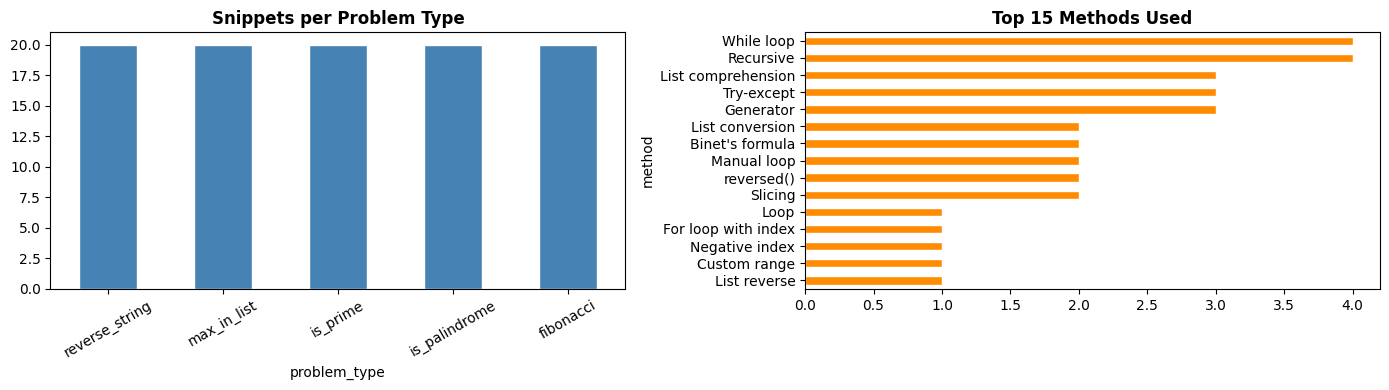

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

meta_df['problem_type'].value_counts().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Snippets per Problem Type', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)

meta_df['method'].value_counts().head(15).plot(
    kind='barh', ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('Top 15 Methods Used', fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('metadata_overview.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Load All Python Snippets

Read every `.py` file into a DataFrame row with columns: `problem`, `filename`, `code`.

In [10]:
def read_file(path):
    try:
        with open(path, 'r', encoding='utf-8', errors='replace') as f:
            return f.read()
    except Exception as e:
        print(f'  ⚠️  {path}: {e}')
        return ''

rows = []
for problem in problem_folders:
    snippets_dir = os.path.join(BASE_PATH, problem, 'snippets')
    for fname in sorted(f for f in os.listdir(snippets_dir) if f.endswith('.py')):
        code = read_file(os.path.join(snippets_dir, fname))
        rows.append({'problem': problem, 'filename': fname, 'code': code})

snippets_df = pd.DataFrame(rows)
print(f'✅ Loaded {len(snippets_df)} snippets across {snippets_df.problem.nunique()} problems.')
snippets_df.head(4)

✅ Loaded 100 snippets across 5 problems.


,problem,filename,code
0,fibonacci,snip_01.py,"def fibonacci(n):\n seq = [0, 1]\n for i..."
1,fibonacci,snip_02.py,def fibonacci(n):\n if n <= 1:\n ret...
2,fibonacci,snip_03.py,"def fibonacci(n):\n a, b = 0, 1\n result..."
3,fibonacci,snip_04.py,def fibonacci(n):\n return [int(((1.618034)...


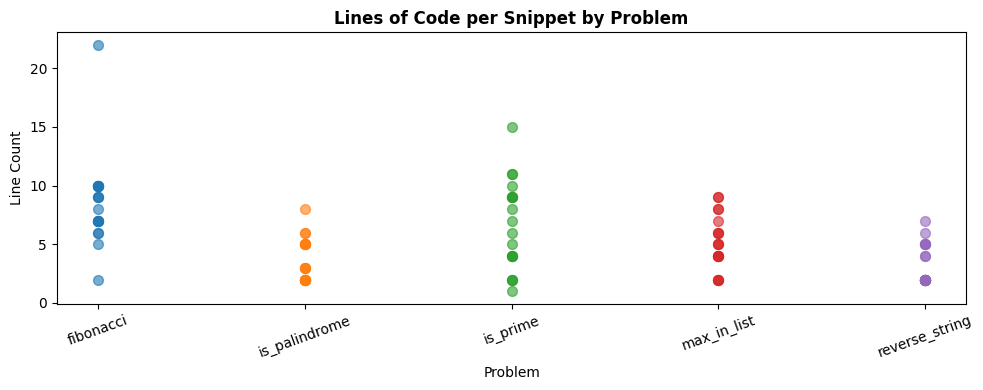

                count  mean  std  min  25%  50%   75%   max
problem                                                    
fibonacci        20.0   8.6  3.8  2.0  7.0  8.5  10.0  22.0
is_palindrome    20.0   3.6  1.8  2.0  2.0  3.0   5.0   8.0
is_prime         20.0   6.6  3.8  1.0  4.0  6.5   9.0  15.0
max_in_list      20.0   5.1  2.3  2.0  4.0  5.0   6.2   9.0
reverse_string   20.0   3.2  1.7  2.0  2.0  2.0   5.0   7.0


In [11]:
# Quick look at code length variation per problem
snippets_df['line_count'] = snippets_df['code'].apply(lambda c: len(c.splitlines()))

fig, ax = plt.subplots(figsize=(10, 4))
for problem, grp in snippets_df.groupby('problem'):
    ax.scatter([problem] * len(grp), grp['line_count'], alpha=0.6, s=50)
ax.set_title('Lines of Code per Snippet by Problem', fontweight='bold')
ax.set_xlabel('Problem')
ax.set_ylabel('Line Count')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('line_count_dist.png', dpi=120, bbox_inches='tight')
plt.show()

print(snippets_df.groupby('problem')['line_count'].describe().round(1))

---
# Preprocessing

Three representations per snippet:

| Column | What it is |
|---|---|
| `code_clean` | Comments / docstrings removed, lowercase, whitespace collapsed |
| `code_tokens` | Token sequence (good for TF-IDF) |
| `ast_nodes` | Sorted list of AST node type names (structural fingerprint) |

In [12]:
# ── Helper: strip docstrings via AST, fall back to regex ──────────────────────
def strip_docstrings(src):
    try:
        tree = ast.parse(src)
        for node in ast.walk(tree):
            if isinstance(node, (ast.FunctionDef, ast.AsyncFunctionDef,
                                  ast.ClassDef, ast.Module)):
                if (node.body
                        and isinstance(node.body[0], ast.Expr)
                        and isinstance(node.body[0].value, ast.Constant)
                        and isinstance(node.body[0].value.value, str)):
                    node.body.pop(0)
        try:
            return ast.unparse(tree)   # Python ≥ 3.9
        except AttributeError:
            pass
    except SyntaxError:
        pass
    # Regex fallback
    src = re.sub(r'#.*', '', src)
    src = re.sub(r"\'\'\'.*?\'\'\'|\"\"\".*?\"\"\"", '', src, flags=re.DOTALL)
    return src


# ── Clean version: lowercase + collapsed whitespace ───────────────────────────
def normalize(src):
    src = strip_docstrings(src)
    src = src.lower()
    return re.sub(r'\s+', ' ', src).strip()


# ── Token sequence using Python's tokenize module ─────────────────────────────
SKIP = {tokenize.COMMENT, tokenize.NEWLINE, tokenize.NL,
        tokenize.ENCODING, tokenize.ENDMARKER,
        tokenize.INDENT, tokenize.DEDENT}

def tokenize_src(src):
    tokens = []
    try:
        clean = strip_docstrings(src)
        for tok in tokenize.generate_tokens(io.StringIO(clean).readline):
            if tok.type not in SKIP and tok.string.strip():
                tokens.append(tok.string.lower())
    except tokenize.TokenizeError:
        tokens = src.lower().split()   # plain-split fallback
    return ' '.join(tokens)


# ── AST node type list ─────────────────────────────────────────────────────────
def ast_node_types(src):
    try:
        return sorted(type(n).__name__ for n in ast.walk(ast.parse(src)))
    except SyntaxError:
        return []


print('🔧 Preprocessing helpers defined.')

🔧 Preprocessing helpers defined.


In [13]:
print('Preprocessing all snippets…')
snippets_df['code_clean']  = snippets_df['code'].apply(normalize)
snippets_df['code_tokens'] = snippets_df['code'].apply(tokenize_src)
snippets_df['ast_nodes']   = snippets_df['code'].apply(ast_node_types)
print('✅ Done.\n')

# ── Sanity check on one sample ─────────────────────────────────────────────────
row = snippets_df.iloc[0]
print(f'Problem : {row.problem} | File: {row.filename}')
print(f'\n[RAW first 200 chars]\n{row.code[:200]}')
print(f'\n[CLEAN first 200 chars]\n{row.code_clean[:200]}')
print(f'\n[TOKENS first 100 chars]\n{row.code_tokens[:100]}')
print(f'\n[AST nodes (first 10)]\n{row.ast_nodes[:10]}')

Preprocessing all snippets…
✅ Done.

Problem : fibonacci | File: snip_01.py

[RAW first 200 chars]
def fibonacci(n):
    seq = [0, 1]
    for i in range(2, n):
        seq.append(seq[-1] + seq[-2])
    return seq[:n]

[CLEAN first 200 chars]
def fibonacci(n): seq = [0, 1] for i in range(2, n): seq.append(seq[-1] + seq[-2]) return seq[:n]

[TOKENS first 100 chars]
def fibonacci ( n ) : seq = [ 0 , 1 ] for i in range ( 2 , n ) : seq . append ( seq [ - 1 ] + seq [ 

[AST nodes (first 10)]
['Add', 'Assign', 'Attribute', 'BinOp', 'Call', 'Call', 'Constant', 'Constant', 'Constant', 'Constant']


---
## Build Balanced Pairs

**Positive (label=1):** two snippets from the **same** problem folder  
**Negative (label=0):** two snippets from **different** problem folders  

With 6 problems × 20 snippets each → C(20,2)=190 positive pairs per problem → **1140 positives**.  
We sample an equal number of negatives to keep the dataset balanced.

In [14]:
np.random.seed(42)
pairs = []

# ── POSITIVE PAIRS ─────────────────────────────────────────────────────────────
for problem, group in snippets_df.groupby('problem'):
    idx = group.index.tolist()
    for i, j in itertools.combinations(idx, 2):
        pairs.append(dict(
            problem_a = problem,
            problem_b = problem,
            file_a    = snippets_df.loc[i, 'filename'],
            file_b    = snippets_df.loc[j, 'filename'],
            clean_a   = snippets_df.loc[i, 'code_clean'],
            clean_b   = snippets_df.loc[j, 'code_clean'],
            tokens_a  = snippets_df.loc[i, 'code_tokens'],
            tokens_b  = snippets_df.loc[j, 'code_tokens'],
            ast_a     = snippets_df.loc[i, 'ast_nodes'],
            ast_b     = snippets_df.loc[j, 'ast_nodes'],
            label     = 1
        ))

n_pos = len(pairs)
print(f'Positive pairs: {n_pos}')

# ── NEGATIVE PAIRS (random cross-problem sampling) ────────────────────────────
all_problems = snippets_df['problem'].unique()
collected    = 0

while collected < n_pos:
    pa, pb = np.random.choice(all_problems, size=2, replace=False)
    ra = snippets_df[snippets_df.problem == pa].sample(1).iloc[0]
    rb = snippets_df[snippets_df.problem == pb].sample(1).iloc[0]
    pairs.append(dict(
        problem_a = pa,
        problem_b = pb,
        file_a    = ra['filename'],
        file_b    = rb['filename'],
        clean_a   = ra['code_clean'],
        clean_b   = rb['code_clean'],
        tokens_a  = ra['code_tokens'],
        tokens_b  = rb['code_tokens'],
        ast_a     = ra['ast_nodes'],
        ast_b     = rb['ast_nodes'],
        label     = 0
    ))
    collected += 1

pairs_df = pd.DataFrame(pairs).sample(frac=1, random_state=42).reset_index(drop=True)
print(f'Negative pairs: {(pairs_df.label==0).sum()}')
print(f'\n✅ Total pairs: {len(pairs_df)}  (balanced: {pairs_df.label.value_counts().to_dict()})')
pairs_df[['problem_a','problem_b','file_a','file_b','label']].head(6)

Positive pairs: 950
Negative pairs: 950

✅ Total pairs: 1900  (balanced: {0: 950, 1: 950})


,problem_a,problem_b,file_a,file_b,label
0,reverse_string,is_palindrome,snip_09.py,snip_15.py,0
1,fibonacci,fibonacci,snip_07.py,snip_20.py,1
2,is_prime,is_prime,snip_14.py,snip_20.py,1
3,is_prime,is_prime,snip_11.py,snip_13.py,1
4,is_palindrome,fibonacci,snip_07.py,snip_11.py,0
5,is_prime,max_in_list,snip_16.py,snip_11.py,0


---
## Feature Engineering

Five interpretable similarity features, each capturing a different aspect:

| Feature | Captures |
|---|---|
| `tfidf_cosine` | Weighted token-level textual similarity |
| `token_jaccard` | Vocabulary overlap |
| `edit_sim` | Character-level edit similarity |
| `ast_jaccard` | Structural (AST node type) similarity |
| `len_ratio` | Relative code length (style proxy) |

In [15]:
# ── 1. TF-IDF Cosine ──────────────────────────────────────────────────────────
print('1/5  TF-IDF cosine…')
all_tokens = pd.concat([pairs_df['tokens_a'], pairs_df['tokens_b']]).tolist()
tfidf      = TfidfVectorizer(analyzer='word', ngram_range=(1, 2),
                              min_df=1, max_features=8000)
tfidf.fit(all_tokens)

va = tfidf.transform(pairs_df['tokens_a'])
vb = tfidf.transform(pairs_df['tokens_b'])
pairs_df['tfidf_cosine'] = [
    cosine_similarity(va[i], vb[i])[0][0] for i in range(len(pairs_df))
]

# ── 2. Token Jaccard ──────────────────────────────────────────────────────────
print('2/5  Token Jaccard…')
def jaccard(s1, s2):
    a, b = set(s1.split()), set(s2.split())
    return len(a & b) / len(a | b) if (a or b) else 0.0

pairs_df['token_jaccard'] = pairs_df.apply(
    lambda r: jaccard(r['tokens_a'], r['tokens_b']), axis=1)

# ── 3. Normalised Edit Similarity ─────────────────────────────────────────────
print('3/5  Edit distance (may take ~60 s)…')
def edit_sim(s1, s2, cap=600):
    s1, s2   = s1[:cap], s2[:cap]
    max_len  = max(len(s1), len(s2), 1)
    return 1.0 - editdistance.eval(s1, s2) / max_len

pairs_df['edit_sim'] = pairs_df.apply(
    lambda r: edit_sim(r['clean_a'], r['clean_b']), axis=1)

# ── 4. AST Node Jaccard ───────────────────────────────────────────────────────
print('4/5  AST Jaccard…')
def ast_jacc(a, b):
    sa, sb = set(a), set(b)
    return len(sa & sb) / len(sa | sb) if (sa or sb) else 0.0

pairs_df['ast_jaccard'] = pairs_df.apply(
    lambda r: ast_jacc(r['ast_a'], r['ast_b']), axis=1)

# ── 5. Length Ratio ───────────────────────────────────────────────────────────
print('5/5  Length ratio…')
pairs_df['len_ratio'] = pairs_df.apply(
    lambda r: min(len(r['clean_a']), len(r['clean_b'])) /
              max(len(r['clean_a']), len(r['clean_b']), 1), axis=1)

FEATURES = ['tfidf_cosine', 'token_jaccard', 'edit_sim', 'ast_jaccard', 'len_ratio']
print('\n✅ All features computed!')
pairs_df[FEATURES + ['label']].describe().round(3)

1/5  TF-IDF cosine…
2/5  Token Jaccard…
3/5  Edit distance (may take ~60 s)…
4/5  AST Jaccard…
5/5  Length ratio…

✅ All features computed!


,tfidf_cosine,token_jaccard,edit_sim,ast_jaccard,len_ratio,label
count,1900.000,1900.000,1900.000,1900.000,1900.000,1900.0
mean,0.139,0.403,0.342,0.542,0.693,0.5
std,0.186,0.166,0.146,0.129,0.200,0.5
min,0.000,0.125,0.093,0.222,0.106,0.0
25%,0.020,0.280,0.237,0.450,0.549,0.0
50%,0.060,0.370,0.306,0.522,0.719,0.5
75%,0.174,0.500,0.416,0.615,0.863,1.0
max,1.000,1.000,1.000,1.000,1.000,1.0


---
## Feature Analysis & Visualisation

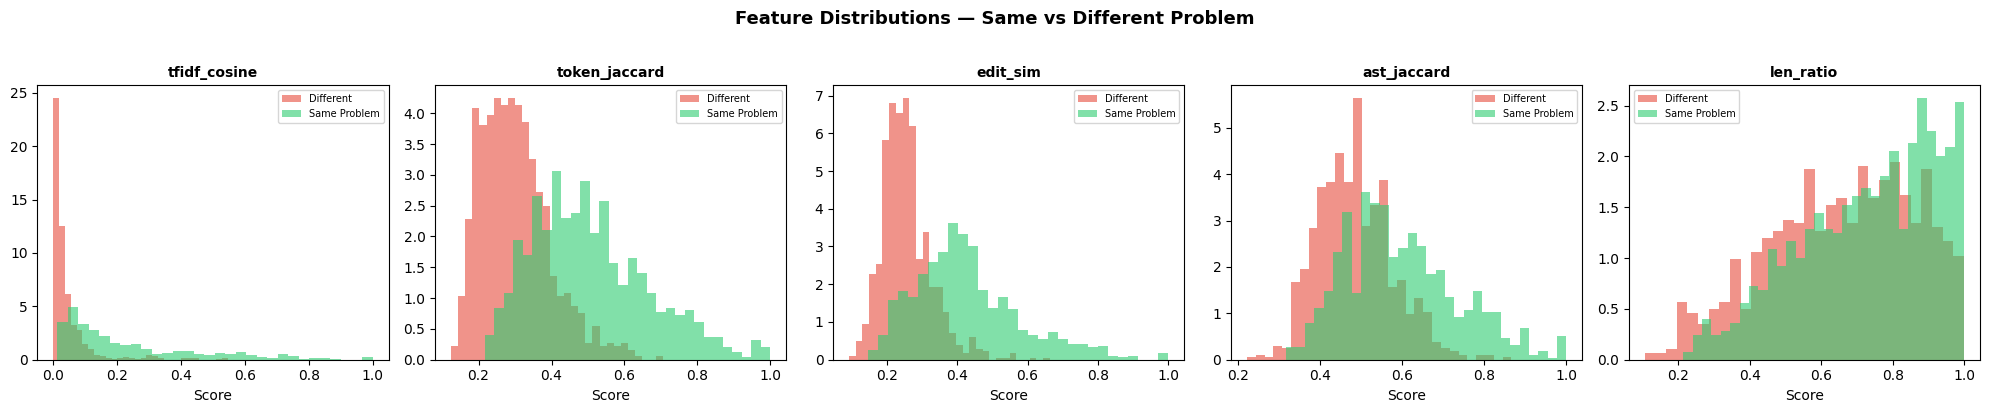

In [16]:
# ── Per-feature distribution: similar vs dissimilar ───────────────────────────
fig, axes = plt.subplots(1, len(FEATURES), figsize=(20, 4))
colors = {0: '#e74c3c', 1: '#2ecc71'}
names  = {0: 'Different', 1: 'Same Problem'}

for ax, feat in zip(axes, FEATURES):
    for lbl in [0, 1]:
        ax.hist(pairs_df.loc[pairs_df.label == lbl, feat],
                bins=30, alpha=0.6, color=colors[lbl],
                label=names[lbl], density=True)
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.set_xlabel('Score')
    ax.legend(fontsize=7)

plt.suptitle('Feature Distributions — Same vs Different Problem', y=1.02,
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Train / Test Split

In [17]:
X = pairs_df[FEATURES].values
y = pairs_df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Scale for Logistic Regression; tree models will use raw features
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {len(X_train)} pairs   Test: {len(X_test)} pairs')
print(f'Positive rate in train: {y_train.mean():.2%}')

Train: 1520 pairs   Test: 380 pairs
Positive rate in train: 50.00%


---
## Baseline: TF-IDF Cosine Threshold

just find the best decision threshold on `tfidf_cosine` alone.

In [18]:
# Sweep thresholds on training set to pick the best one
train_cos = X_train[:, FEATURES.index('tfidf_cosine')]
test_cos  = X_test[:,  FEATURES.index('tfidf_cosine')]

best_t, best_acc = 0.5, 0
for t in np.linspace(0, 1, 200):
    acc = accuracy_score(y_train, (train_cos >= t).astype(int))
    if acc > best_acc:
        best_acc, best_t = acc, t

base_preds = (test_cos >= best_t).astype(int)
base_acc   = accuracy_score(y_test, base_preds)
base_auc   = roc_auc_score(y_test, test_cos)

print(f'📌 Baseline — threshold = {best_t:.3f}')
print(f'   Accuracy : {base_acc:.4f}   ROC-AUC : {base_auc:.4f}\n')
print(classification_report(y_test, base_preds,
                              target_names=['Different', 'Same Problem']))

📌 Baseline — threshold = 0.050
   Accuracy : 0.8579   ROC-AUC : 0.9198

              precision    recall  f1-score   support

   Different       0.87      0.84      0.85       190
Same Problem       0.84      0.88      0.86       190

    accuracy                           0.86       380
   macro avg       0.86      0.86      0.86       380
weighted avg       0.86      0.86      0.86       380



# Train three Models

In [19]:
MODEL_DEFS = {
    'Logistic Regression': (
        LogisticRegression(max_iter=1000, random_state=42),
        X_train_sc, X_test_sc),
    'Random Forest': (
        RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
        X_train, X_test),
    'Gradient Boosting': (
        GradientBoostingClassifier(n_estimators=300, learning_rate=0.05,
                                   max_depth=4, random_state=42),
        X_train, X_test),
}

results = {}
for name, (model, Xtr, Xte) in MODEL_DEFS.items():
    model.fit(Xtr, y_train)
    preds = model.predict(Xte)
    probs = model.predict_proba(Xte)[:, 1]
    results[name] = dict(
        model    = model,
        preds    = preds,
        probs    = probs,
        accuracy = accuracy_score(y_test, preds),
        auc      = roc_auc_score(y_test, probs)
    )
    print(f'{name:<26} Accuracy: {results[name]["accuracy"]:.4f}   ROC-AUC: {results[name]["auc"]:.4f}')

Logistic Regression        Accuracy: 0.8605   ROC-AUC: 0.9373
Random Forest              Accuracy: 0.8921   ROC-AUC: 0.9744
Gradient Boosting          Accuracy: 0.8895   ROC-AUC: 0.9716


---
## Confusion Matrices & ROC Curves

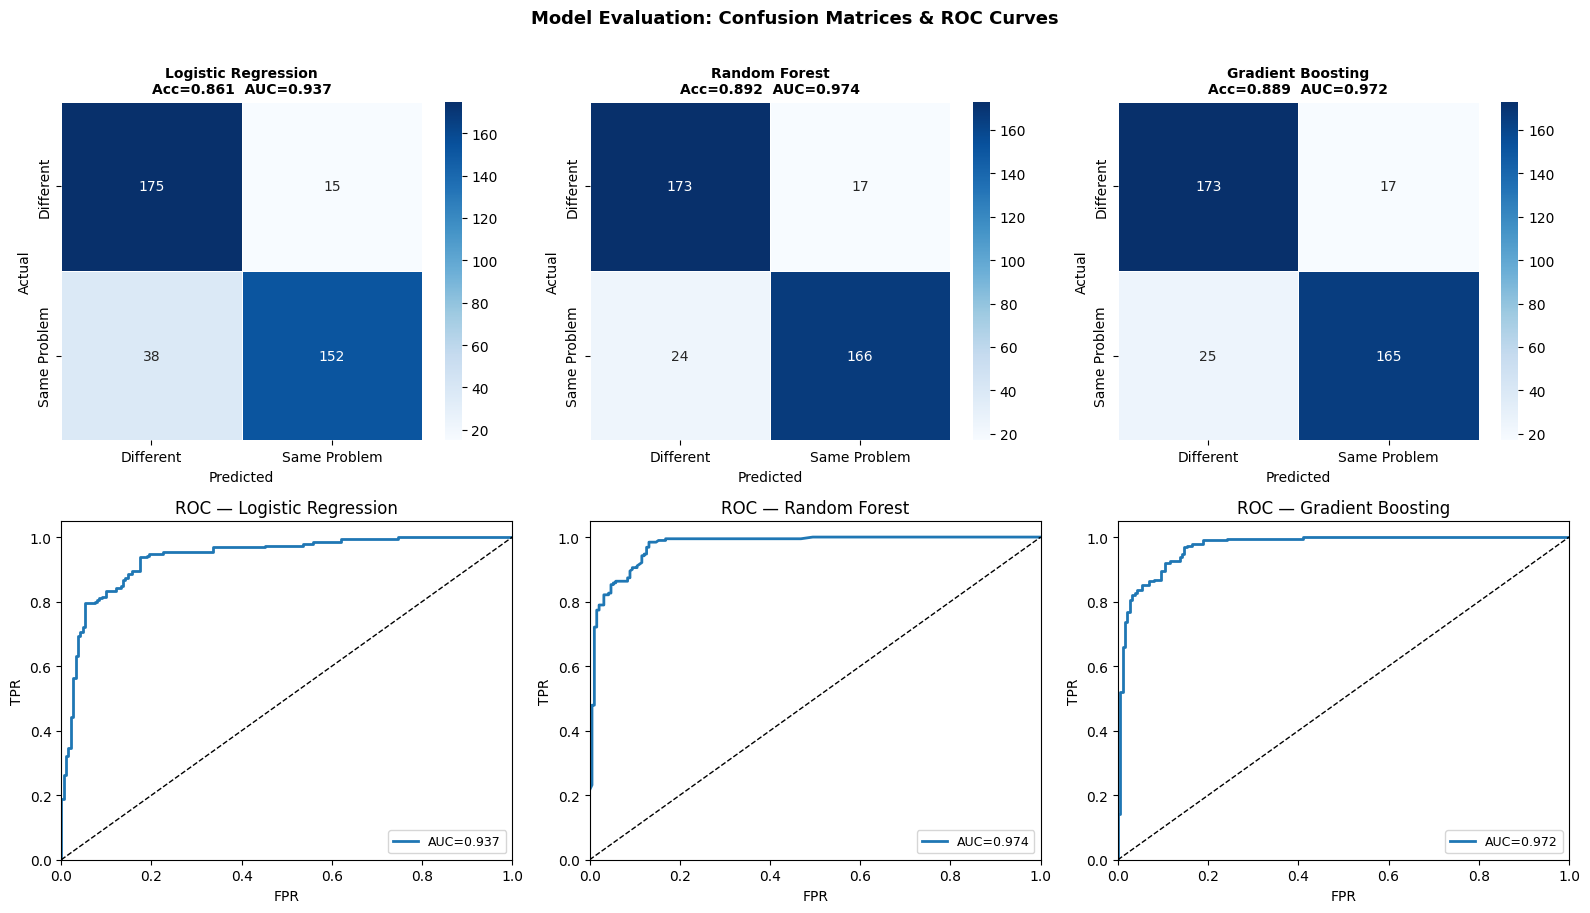

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
class_names = ['Different', 'Same Problem']

for col, (name, res) in enumerate(results.items()):
    # Confusion matrix
    cm = confusion_matrix(y_test, res['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[0, col], linewidths=0.5)
    axes[0, col].set_title(
        f'{name}\nAcc={res["accuracy"]:.3f}  AUC={res["auc"]:.3f}',
        fontsize=10, fontweight='bold')
    axes[0, col].set_xlabel('Predicted')
    axes[0, col].set_ylabel('Actual')

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, res['probs'])
    axes[1, col].plot(fpr, tpr, lw=2, label=f"AUC={res['auc']:.3f}")
    axes[1, col].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[1, col].set(xlim=[0,1], ylim=[0,1.05],
                     xlabel='FPR', ylabel='TPR',
                     title=f'ROC — {name}')
    axes[1, col].legend(loc='lower right', fontsize=9)

plt.suptitle('Model Evaluation: Confusion Matrices & ROC Curves',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Feature Importance (Best Model)

🏆 Best model: Random Forest  (AUC = 0.9744)


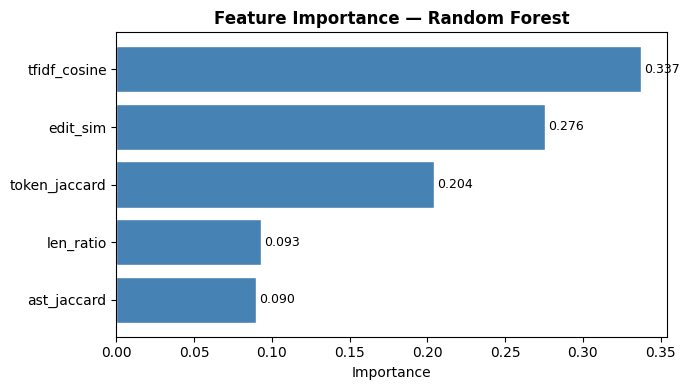

In [21]:
best_name  = max(results, key=lambda k: results[k]['auc'])
best_model = results[best_name]['model']
print(f'🏆 Best model: {best_name}  (AUC = {results[best_name]["auc"]:.4f})')

if hasattr(best_model, 'feature_importances_'):
    imp = best_model.feature_importances_
else:
    imp = np.abs(best_model.coef_[0])

fi = pd.DataFrame({'feature': FEATURES, 'importance': imp}).sort_values('importance')

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(fi['feature'], fi['importance'], color='steelblue', edgecolor='white')
for bar, val in zip(bars, fi['importance']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
ax.set_xlabel('Importance')
ax.set_title(f'Feature Importance — {best_name}', fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Per-Problem Similarity Heatmap

Average TF-IDF cosine similarity between every pair of problem types.  
Diagonal = within-problem similarity (should be highest).

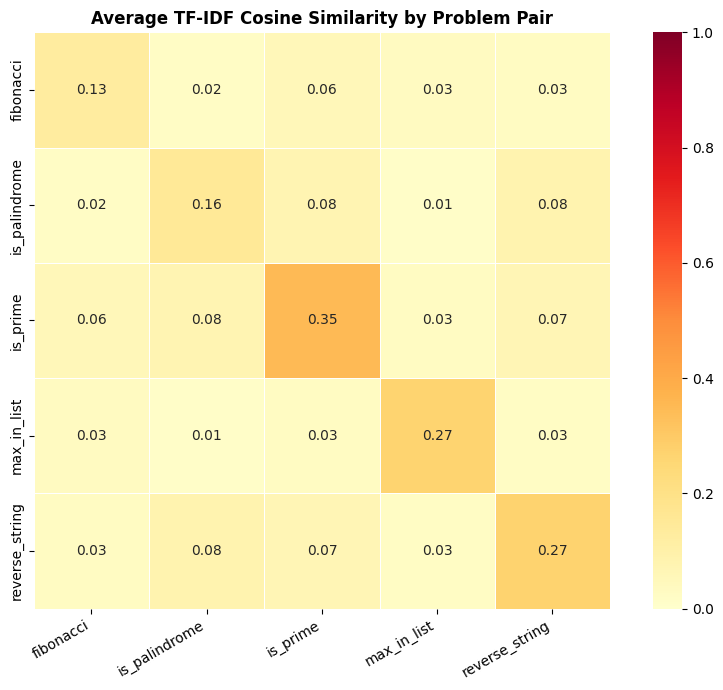

In [22]:
from collections import defaultdict

# Aggregate: for every (problem_a, problem_b) combination collect mean cosine
agg = defaultdict(list)
for _, row in pairs_df.iterrows():
    key = tuple(sorted([row['problem_a'], row['problem_b']]))
    agg[key].append(row['tfidf_cosine'])

# Build a symmetric DataFrame
hm = pd.DataFrame(index=problem_folders, columns=problem_folders, dtype=float)
for pa in problem_folders:
    for pb in problem_folders:
        key = tuple(sorted([pa, pb]))
        hm.loc[pa, pb] = np.mean(agg[key]) if agg[key] else (1.0 if pa == pb else 0.0)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(hm.astype(float), annot=True, fmt='.2f', cmap='YlOrRd',
            vmin=0, vmax=1, linewidths=0.5, square=True, ax=ax)
ax.set_title('Average TF-IDF Cosine Similarity by Problem Pair',
             fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('problem_similarity_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Inspect Example Predictions

In [23]:
# Attach best-model predictions to the test slice
test_slice = pairs_df.iloc[-len(X_test):].copy().reset_index(drop=True)
test_slice['pred']       = results[best_name]['preds']
test_slice['confidence'] = results[best_name]['probs'].round(3)

correct = test_slice[test_slice.label == test_slice.pred]
wrong   = test_slice[test_slice.label != test_slice.pred]

print('=== CORRECT PREDICTIONS (first 5) ===')
for _, r in correct.head(5).iterrows():
    tag = 'SAME' if r.label == 1 else 'DIFF'
    print(f'  [{tag}] {r.problem_a} vs {r.problem_b}  conf={r.confidence}')

print(f'\n=== MISCLASSIFIED ({len(wrong)} total) ===')
if len(wrong) == 0:
    print('  🎉 Perfect on this slice!')
else:
    for _, r in wrong.head(5).iterrows():
        true_l = 'SAME' if r.label == 1 else 'DIFF'
        pred_l = 'SAME' if r.pred  == 1 else 'DIFF'
        print(f'  [True={true_l} Pred={pred_l}] {r.problem_a} vs {r.problem_b}  conf={r.confidence}')

=== CORRECT PREDICTIONS (first 5) ===
  [DIFF] fibonacci vs is_prime  conf=0.0
  [DIFF] reverse_string vs fibonacci  conf=0.403
  [SAME] is_palindrome vs is_palindrome  conf=0.66
  [SAME] reverse_string vs reverse_string  conf=0.79
  [DIFF] max_in_list vs is_palindrome  conf=0.29

=== MISCLASSIFIED (177 total) ===
  [True=DIFF Pred=SAME] is_palindrome vs is_prime  conf=0.943
  [True=DIFF Pred=SAME] max_in_list vs is_palindrome  conf=0.937
  [True=SAME Pred=DIFF] is_prime vs is_prime  conf=0.003
  [True=DIFF Pred=SAME] is_palindrome vs is_prime  conf=0.877
  [True=DIFF Pred=SAME] is_prime vs fibonacci  conf=0.517


---
## Final Summary

In [24]:
print('=' * 62)
print('  FINAL RESULTS SUMMARY')
print('=' * 62)
print(f'  Snippets  : {len(snippets_df)} across {len(problem_folders)} problems')
print(f'  Pairs     : {len(pairs_df)}  ({(pairs_df.label==1).sum()} pos / {(pairs_df.label==0).sum()} neg)')
print(f'  Features  : {FEATURES}')
print()
print(f'  {"Model":<28} {"Accuracy":>10}  {"ROC-AUC":>10}')
print(f'  {"-"*28} {"-"*10}  {"-"*10}')
print(f'  {"Baseline (cosine thresh.)":<28} {base_acc:>10.4f}  {base_auc:>10.4f}')
for name, res in results.items():
    marker = '  ← best' if name == best_name else ''
    print(f'  {name:<28} {res["accuracy"]:>10.4f}  {res["auc"]:>10.4f}{marker}')
print('=' * 62)
print()
print('Saved plots:')
for f in ['metadata_overview.png', 'line_count_dist.png',
          'feature_distributions.png', 'feature_correlation.png',
          'model_evaluation.png', 'feature_importance.png',
          'problem_similarity_heatmap.png']:
    print(f'  {f}')

  FINAL RESULTS SUMMARY
  Snippets  : 100 across 5 problems
  Pairs     : 1900  (950 pos / 950 neg)
  Features  : ['tfidf_cosine', 'token_jaccard', 'edit_sim', 'ast_jaccard', 'len_ratio']

  Model                          Accuracy     ROC-AUC
  ---------------------------- ----------  ----------
  Baseline (cosine thresh.)        0.8579      0.9198
  Logistic Regression              0.8605      0.9373
  Random Forest                    0.8921      0.9744  ← best
  Gradient Boosting                0.8895      0.9716

Saved plots:
  metadata_overview.png
  line_count_dist.png
  feature_distributions.png
  feature_correlation.png
  model_evaluation.png
  feature_importance.png
  problem_similarity_heatmap.png


# Key Takeaways

- The dataset contained **100 code snippets across 5 problems**, which produced **1,900 balanced pairs**  
  (**950 positive** and **950 negative**).
- The feature set combined **textual**, **token-level**, and **structural** similarity signals:
  `tfidf_cosine`, `token_jaccard`, `edit_sim`, `ast_jaccard`, and `len_ratio`.
- The **baseline TF-IDF cosine threshold** was already strong, which shows that many snippets from the same problem share noticeable lexical overlap.
- Among the trained models, **Random Forest performed best**:
  - **Accuracy:** 0.8921
  - **ROC-AUC:** 0.9744
- **Gradient Boosting** was very close to Random Forest:
  - **Accuracy:** 0.8895
  - **ROC-AUC:** 0.9716
- **Logistic Regression** improved over the baseline but stayed below the tree-based models.
- The error analysis shows an important pattern:
  - Some **different problems were predicted as same** because they share similar syntax, loops, variables, or simple algorithmic structure.
  - Some **same-problem pairs were predicted as different** because implementations vary a lot in style, formatting, or control flow.
- This means the model is learning **code similarity**, but not full **semantic equivalence**.  
  It works well for capturing patterns, but it can still confuse snippets that look similar at the surface level.

## Interpretation

The results suggest that:

1. **Surface features are useful** for code similarity detection.
2. **Structural features from AST help**, but they are not enough alone to fully understand program meaning.
3. A tree-based model like **Random Forest** can combine multiple similarity signals better than a simple threshold or linear classifier.
4. The hardest cases are pairs where:
   - two different problems use very similar code templates, or
   - the same problem is solved using very different programming styles.

## Final Conclusion

This project successfully built a **balanced code-similarity classifier** that can decide whether two Python snippets likely solve the same problem.  
The best model, **Random Forest**, achieved the strongest overall performance with **0.9744 ROC-AUC**, showing that combining token, character, AST, and length-based features is effective for this task.

## Saved Outputs

The analysis generated these plots:

- `metadata_overview.png`
- `line_count_dist.png`
- `feature_distributions.png`
- `feature_correlation.png`
- `model_evaluation.png`
- `feature_importance.png`
- `problem_similarity_heatmap.png`